In [3]:
import os
import matplotlib.pyplot as plt

output_dir = os.path.join("..", "figuras", "extra")
os.makedirs(output_dir, exist_ok=True)

C:\Users\Juanfran cd\AppData\Local\Temp\ipykernel_3948\3457213344.py:92: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(
C:\Users\Juanfran cd\AppData\Local\Temp\ipykernel_3948\3457213344.py:92: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(
C:\Users\Juanfran cd\AppData\Local\Temp\ipykernel_3948\3457213344.py:92: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(
C:\Users\Juanfran cd\AppData\Local\Temp\ipykernel_3948\3457213344.py:92: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may b

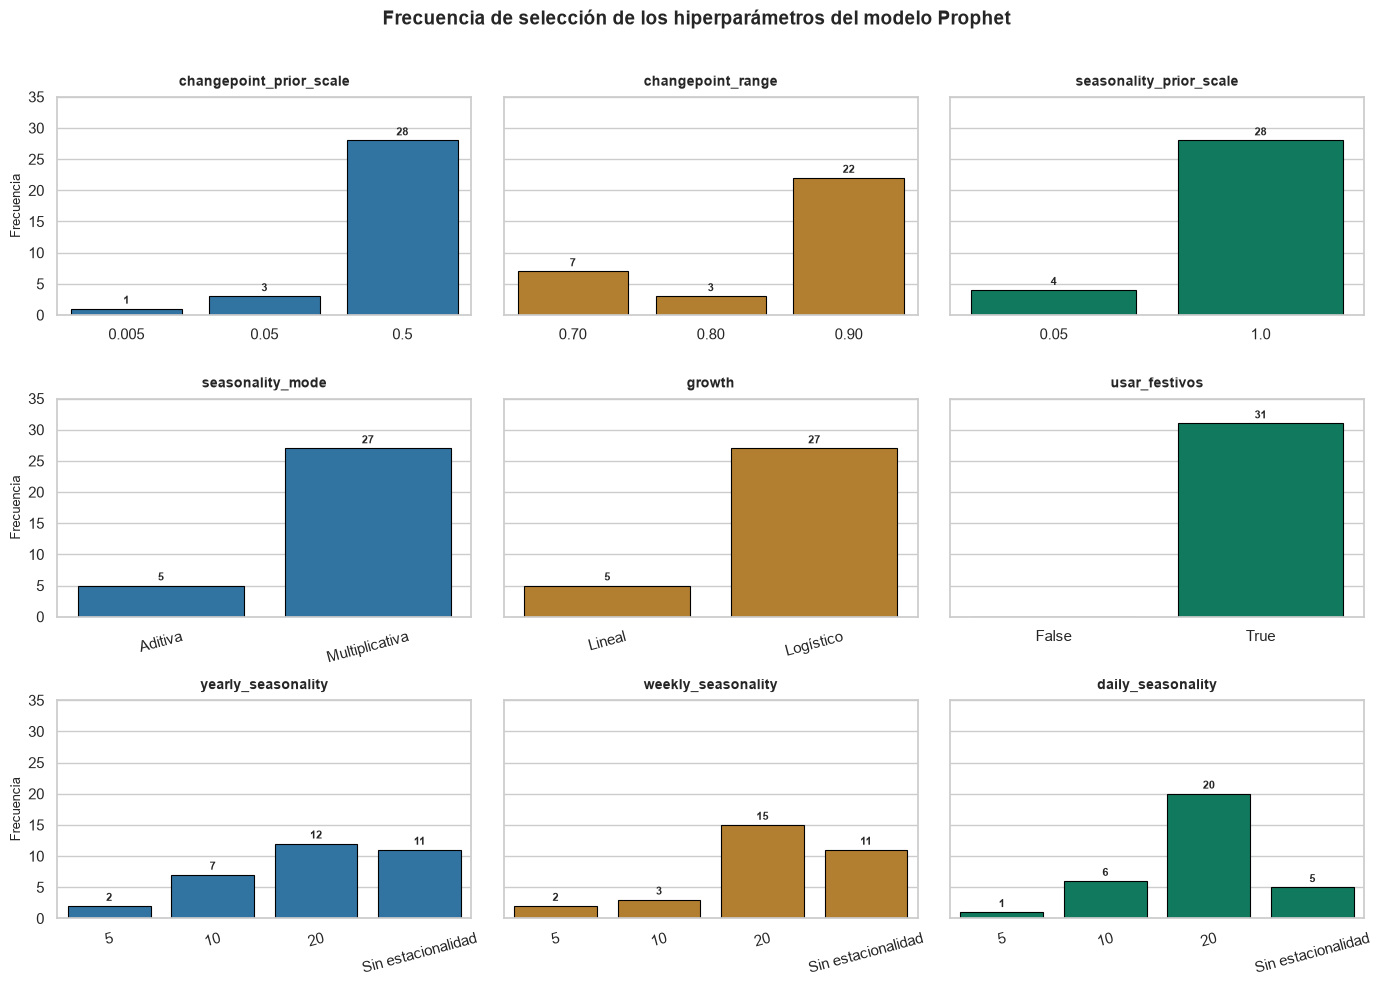

In [4]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Configuración de estilo global para que se parezca al de la imagen (estilo Seaborn / ggplot)
sns.set_theme(style="whitegrid")
plt.rcParams.update(
    {
        "font.family": "sans-serif",
        "font.size": 9,
        "axes.titlesize": 10,
        "axes.titleweight": "bold",
        "axes.labelsize": 9,
    }
)

# 1. Datos organizados según tu tabla
data = {
    "changepoint_prior_scale": {"0.005": 1, "0.05": 3, "0.5": 28},
    "changepoint_range": {"0.70": 7, "0.80": 3, "0.90": 22},
    "seasonality_prior_scale": {"0.05": 4, "1.0": 28},
    "seasonality_mode": {"Aditiva": 5, "Multiplicativa": 27},
    "growth": {"Lineal": 5, "Logístico": 27},
    "usar_festivos": {"False": 0, "True": 31},
    "yearly_seasonality": {
        "5": 2,
        "10": 7,
        "20": 12,
        "Sin estacionalidad": 11,
    },
    "weekly_seasonality": {
        "5": 2,
        "10": 3,
        "20": 15,
        "Sin estacionalidad": 11,
    },
    "daily_seasonality": {"5": 1, "10": 6, "20": 20, "Sin estacionalidad": 5},
}

# 2. Crear la figura de 3 filas x 3 columnas
fig, axes = plt.subplots(3, 3, figsize=(14, 10), sharey=True)
axes = axes.flatten()  # Aplanar la matriz 3x3 para iterar fácilmente

# Paleta de colores similar a la imagen (Azul, Marrón/Naranja, Verde)
colors = ["#1f77b4", "#c88219", "#008a65"]

# 3. Dibujar cada subplot
for i, (param_name, param_data) in enumerate(data.items()):
    ax = axes[i]

    # Convertir dict a DataFrame para Seaborn
    df_temp = pd.DataFrame(
        list(param_data.items()), columns=["Valor", "Frecuencia"]
    )

    # Asignar color alternado por gráfico según la columna
    color = colors[i % 3]

    # Gráficos de barras
    bars = sns.barplot(
        data=df_temp,
        x="Valor",
        y="Frecuencia",
        ax=ax,
        color=color,
        edgecolor="black",
        linewidth=0.8,
    )

    # Título y etiquetas del eje
    ax.set_title(param_name, pad=8)
    ax.set_xlabel("")
    ax.set_ylabel("Frecuencia" if i % 3 == 0 else "")  # Solo mostrar eje Y en la columna izquierda
    ax.set_ylim(0, 35)

    # Añadir el número (frecuencia) encima de cada barra
    for p in bars.patches:
        height = p.get_height()
        if height > 0:  # No mostrar cero
            ax.annotate(
                f"{int(height)}",
                (p.get_x() + p.get_width() / 2.0, height),
                ha="center",
                va="bottom",
                xytext=(0, 2),
                textcoords="offset points",
                fontsize=8,
                fontweight="bold",
            )

    # Ajustar etiquetas largas del eje X (p. ej., "Sin estacionalidad")
    ax.set_xticklabels(
        ax.get_xticklabels(),
        rotation=15 if any(len(l.get_text()) > 8 for l in ax.get_xticklabels()) else 0,
    )

# 4. Ajustar título principal y diseño general
fig.suptitle(
    "Frecuencia de selección de los hiperparámetros del modelo Prophet",
    fontsize=14,
    fontweight="bold",
    y=0.98,
)

plt.tight_layout(rect=[0, 0, 1, 0.96])

# Mostrar / Guardar
file_path = os.path.join(output_dir, "hiperparametros_prophet_barras.png")
plt.savefig(file_path, bbox_inches="tight", dpi=300)
plt.show()

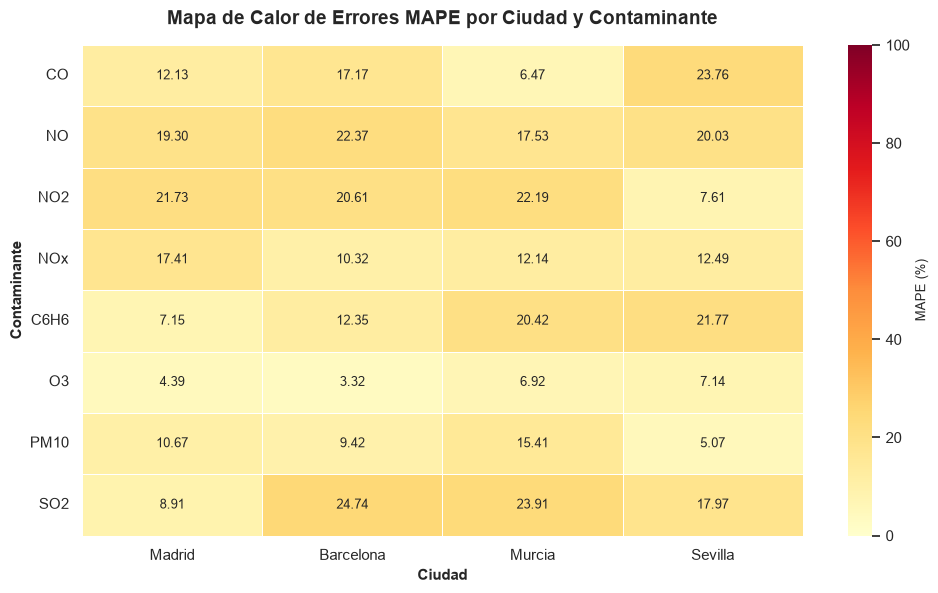

In [5]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 1. Estructura de los datos con los errores MAPE
data = {
    "Madrid": {
        "CO": 12.13,
        "NO": 19.30,
        "NO2": 21.73,
        "NOx": 17.41,
        "C6H6": 7.15,
        "O3": 4.39,
        "PM10": 10.67,
        "SO2": 8.91,
    },
    "Barcelona": {
        "CO": 17.17,
        "NO": 22.37,
        "NO2": 20.61,
        "NOx": 10.32,
        "C6H6": 12.35,
        "O3": 3.32,
        "PM10": 9.42,
        "SO2": 24.74,
    },
    "Murcia": {
        "CO": 6.47,
        "NO": 17.53,
        "NO2": 22.19,
        "NOx": 12.14,
        "C6H6": 20.42,
        "O3": 6.92,
        "PM10": 15.41,
        "SO2": 23.91,
    },
    "Sevilla": {
        "CO": 23.76,
        "NO": 20.03,
        "NO2": 7.61,
        "NOx": 12.49,
        "C6H6": 21.77,
        "O3": 7.14,
        "PM10": 5.07,
        "SO2": 17.97,
    },
}

# 2. Convertir el diccionario en un DataFrame de pandas
df = pd.DataFrame(data)

# 3. Configuración del tamaño de la figura
plt.figure(figsize=(10, 6))

# 4. Crear el mapa de calor (Heatmap)
ax = sns.heatmap(
    df,
    annot=True,  # Mostrar los valores en las celdas
    fmt=".2f",  # Formato con 2 decimales
    cmap="YlOrRd",  # Gradiente de color: Amarillo (bajo error) a Rojo (alto error)
    vmin=0,  # Rango mínimo del mapa de calor
    vmax=100,  # Rango máximo del mapa de calor
    linewidths=0.5,  # Separación entre celdas
    cbar_kws={"label": "MAPE (%)"},  # Etiqueta de la barra de color
)

# 5. Personalización de títulos y etiquetas
plt.title(
    "Mapa de Calor de Errores MAPE por Ciudad y Contaminante",
    fontsize=14,
    pad=15,
    fontweight="bold",
)
plt.xlabel("Ciudad", fontsize=11, fontweight="bold")
plt.ylabel("Contaminante", fontsize=11, fontweight="bold")

# Rotar etiquetas para mejor lectura
plt.xticks(rotation=0)
plt.yticks(rotation=0)

plt.tight_layout()

# 6. Guardar y mostrar
file_path = os.path.join(output_dir, "mapa_calor_mape_prophet.png")
plt.savefig(file_path, bbox_inches="tight", dpi=300)
plt.show()

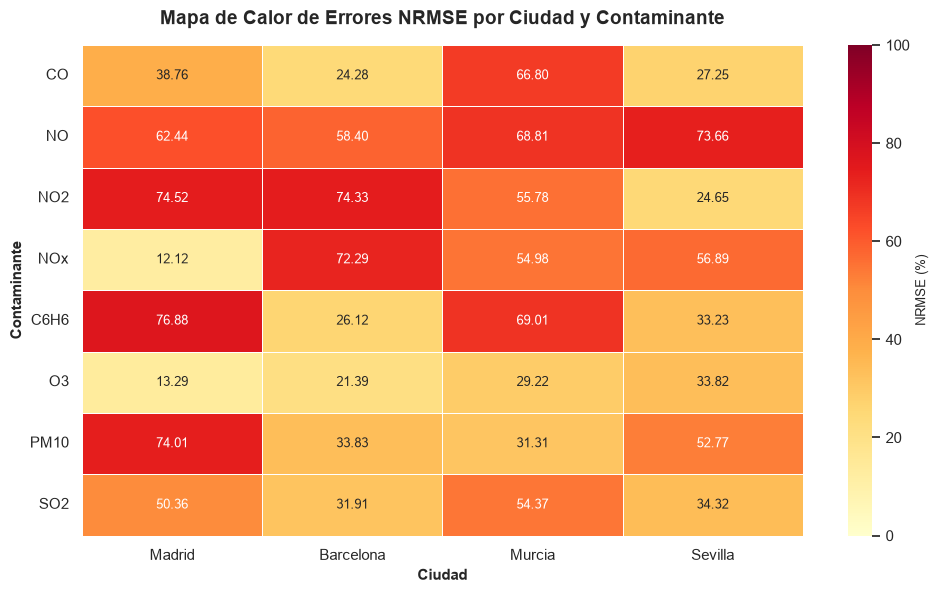

In [6]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 1. Estructura de los datos con los errores NRMSE
data = {
    "Madrid": {
        "CO": 38.76,
        "NO": 62.44,
        "NO2": 74.52,
        "NOx": 12.12,
        "C6H6": 76.88,
        "O3": 13.29,
        "PM10": 74.01,
        "SO2": 50.36,
    },
    "Barcelona": {
        "CO": 24.28,
        "NO": 58.40,
        "NO2": 74.33,
        "NOx": 72.29,
        "C6H6": 26.12,
        "O3": 21.39,
        "PM10": 33.83,
        "SO2": 31.91,
    },
    "Murcia": {
        "CO": 66.80,
        "NO": 68.81,
        "NO2": 55.78,
        "NOx": 54.98,
        "C6H6": 69.01,
        "O3": 29.22,
        "PM10": 31.31,
        "SO2": 54.37,
    },
    "Sevilla": {
        "CO": 27.25,
        "NO": 73.66,
        "NO2": 24.65,
        "NOx": 56.89,
        "C6H6": 33.23,
        "O3": 33.82,
        "PM10": 52.77,
        "SO2": 34.32,
    },
}

# 2. Convertir el diccionario en un DataFrame de pandas
df = pd.DataFrame(data)

# 3. Configuración de la figura
plt.figure(figsize=(10, 6))

# 4. Crear el mapa de calor (Heatmap)
ax = sns.heatmap(
    df,
    annot=True,  # Muestra los valores dentro de cada casilla
    fmt=".2f",  # 2 decimales
    cmap="YlOrRd",  # Gradiente: amarillo (bajo error) a rojo (alto error)
    vmin=0,  # Límite inferior de la escala
    vmax=100,  # Límite superior de la escala
    linewidths=0.5,  # Líneas de división entre celdas
    cbar_kws={"label": "NRMSE (%)"},  # Etiqueta de la barra lateral
)

# 5. Títulos y ejes
plt.title(
    "Mapa de Calor de Errores NRMSE por Ciudad y Contaminante",
    fontsize=14,
    pad=15,
    fontweight="bold",
)
plt.xlabel("Ciudad", fontsize=11, fontweight="bold")
plt.ylabel("Contaminante", fontsize=11, fontweight="bold")

# Mantener las etiquetas de los ejes horizontales
plt.xticks(rotation=0)
plt.yticks(rotation=0)

plt.tight_layout()

# 6. Guardar y mostrar
file_path = os.path.join(output_dir, "mapa_calor_nrmse_prophet.png")
plt.savefig(file_path, bbox_inches="tight", dpi=300)
plt.show()